# Tutorial 10 — Image Segmentation using U-Net

## Objective

This notebook implements **Tutorial 10: Segmentation using U-Net** using PyTorch.

The tutorial focuses on:

- understanding U-Net architecture
- creating image-mask pairs
- training a U-Net segmentation model
- visualizing predicted masks
- changing model layers
- testing different learning rates

For this implementation, a **synthetic segmentation dataset** is used.

Each sample contains:

- an input image with simple random shapes
- a binary mask showing the target object region

Expected folder structure:

```text
Tutorial_10/
├── tutorial_10_unet_segmentation.ipynb
└── images/
```

All generated result images will be saved inside the `images/` folder.


## 1. Import Required Libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Create Synthetic Segmentation Dataset

The synthetic dataset contains simple shapes on noisy backgrounds.

The mask is binary:

```text
0 = background
1 = object region
```

This matches the segmentation task, where the model learns to classify each pixel as background or object.


In [2]:
def create_synthetic_sample(image_size=128):
    # Background image with random low-level noise
    image = np.random.randint(0, 40, size=(image_size, image_size, 3), dtype=np.uint8)

    # Empty binary mask
    mask = np.zeros((image_size, image_size), dtype=np.uint8)

    image_pil = Image.fromarray(image)
    mask_pil = Image.fromarray(mask)

    image_draw = ImageDraw.Draw(image_pil)
    mask_draw = ImageDraw.Draw(mask_pil)

    # Random shape parameters
    shape_type = random.choice(["circle", "rectangle", "ellipse"])
    x1 = random.randint(10, image_size // 2)
    y1 = random.randint(10, image_size // 2)
    x2 = random.randint(image_size // 2, image_size - 10)
    y2 = random.randint(image_size // 2, image_size - 10)

    color = tuple(np.random.randint(120, 255, size=3).tolist())

    if shape_type == "circle" or shape_type == "ellipse":
        image_draw.ellipse([x1, y1, x2, y2], fill=color)
        mask_draw.ellipse([x1, y1, x2, y2], fill=255)
    else:
        image_draw.rectangle([x1, y1, x2, y2], fill=color)
        mask_draw.rectangle([x1, y1, x2, y2], fill=255)

    image = np.array(image_pil).astype(np.float32) / 255.0
    mask = np.array(mask_pil).astype(np.float32) / 255.0

    return image, mask


def generate_synthetic_dataset(num_samples=300, image_size=128):
    images = []
    masks = []

    for _ in range(num_samples):
        image, mask = create_synthetic_sample(image_size=image_size)
        images.append(image)
        masks.append(mask)

    images = np.array(images, dtype=np.float32)
    masks = np.array(masks, dtype=np.float32)

    return images, masks


NUM_SAMPLES = 300
IMAGE_SIZE = 128

images_np, masks_np = generate_synthetic_dataset(
    num_samples=NUM_SAMPLES,
    image_size=IMAGE_SIZE
)

print("Images shape:", images_np.shape)
print("Masks shape:", masks_np.shape)


Images shape: (300, 128, 128, 3)
Masks shape: (300, 128, 128)


## 3. Visualize Synthetic Images and Masks

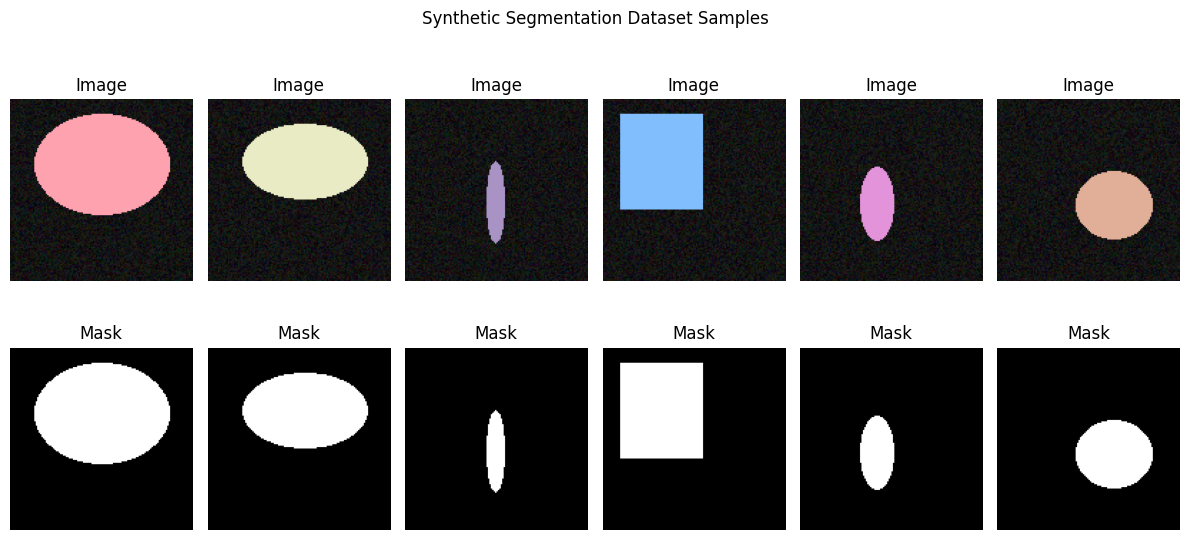

In [3]:
def show_synthetic_samples(images, masks, n_samples=6):
    plt.figure(figsize=(12, 6))

    for i in range(n_samples):
        plt.subplot(2, n_samples, i + 1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(masks[i], cmap="gray")
        plt.title("Mask")
        plt.axis("off")

    plt.suptitle("Synthetic Segmentation Dataset Samples")
    plt.tight_layout()
    plt.savefig("images/tutorial_10_synthetic_dataset_samples.png", dpi=300, bbox_inches="tight")
    plt.show()


show_synthetic_samples(images_np, masks_np, n_samples=6)


## 4. Create PyTorch Dataset and DataLoaders

In [4]:
class SyntheticSegmentationDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        # Image: H x W x C -> C x H x W
        image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        # Mask: H x W -> 1 x H x W
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image_tensor, mask_tensor


full_dataset = SyntheticSegmentationDataset(images_np, masks_np)

train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Train samples: 210
Validation samples: 45
Test samples: 45


# Part A — Define U-Net Model

U-Net has two main paths:

```text
Encoder   → extracts features and downsamples
Decoder   → upsamples and reconstructs segmentation mask
```

The skip connections pass high-resolution features from the encoder to the decoder.


## 5. Define U-Net Building Blocks

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()

        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]

        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))

        self.double_conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=32, dropout=0.0):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels, dropout=dropout)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2, dropout=dropout)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4, dropout=dropout)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8, dropout=dropout)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4, dropout=dropout)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2, dropout=dropout)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels, dropout=dropout)

        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        c3 = torch.cat([u3, e3], dim=1)
        d3 = self.dec3(c3)

        u2 = self.up2(d3)
        c2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(c2)

        u1 = self.up1(d2)
        c1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(c1)

        output = self.out_conv(d1)

        return output


## 6. Test U-Net Output Shape

In [6]:
test_model = UNet(in_channels=3, out_channels=1, base_channels=32).to(device)
dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)

with torch.no_grad():
    dummy_output = test_model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)

total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Input shape: torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 1, 128, 128])
Total parameters: 1928417
Trainable parameters: 1928417


## 7. Loss Function and Metrics

In [7]:
def dice_coefficient(pred_masks, true_masks, threshold=0.5, eps=1e-7):
    pred_masks = torch.sigmoid(pred_masks)
    pred_masks = (pred_masks > threshold).float()

    intersection = (pred_masks * true_masks).sum(dim=(1, 2, 3))
    union = pred_masks.sum(dim=(1, 2, 3)) + true_masks.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)

    return dice.mean().item()


def iou_score(pred_masks, true_masks, threshold=0.5, eps=1e-7):
    pred_masks = torch.sigmoid(pred_masks)
    pred_masks = (pred_masks > threshold).float()

    intersection = (pred_masks * true_masks).sum(dim=(1, 2, 3))
    union = pred_masks.sum(dim=(1, 2, 3)) + true_masks.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)

    return iou.mean().item()


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_coefficient(outputs.detach(), masks)
        total_iou += iou_score(outputs.detach(), masks)

    return total_loss / len(loader), total_dice / len(loader), total_iou / len(loader)


def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()
            total_dice += dice_coefficient(outputs, masks)
            total_iou += iou_score(outputs, masks)

    return total_loss / len(loader), total_dice / len(loader), total_iou / len(loader)


## 8. Training Function

In [8]:
def train_unet_experiment(model, train_loader, val_loader, epochs=15, learning_rate=0.001, experiment_name="unet"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_dice": [],
        "val_dice": [],
        "train_iou": [],
        "val_iou": []
    }

    for epoch in range(epochs):
        train_loss, train_dice, train_iou = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_dice, val_iou = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)
        history["train_iou"].append(train_iou)
        history["val_iou"].append(val_iou)

        print(
            f"{experiment_name} | Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Dice: {train_dice:.4f} | Val Dice: {val_dice:.4f} | "
            f"Train IoU: {train_iou:.4f} | Val IoU: {val_iou:.4f}"
        )

    return history


def plot_history(history, filename, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history["train_dice"], label="Train Dice")
    plt.plot(epochs_range, history["val_dice"], label="Validation Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice Score")
    plt.title("Dice Score")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history["train_iou"], label="Train IoU")
    plt.plot(epochs_range, history["val_iou"], label="Validation IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.title("IoU")
    plt.legend()
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# Part B — Train Baseline U-Net

The baseline U-Net uses:

```text
base_channels = 32
learning_rate = 0.001
```


Baseline U-Net | Epoch 1/15 | Train Loss: 0.4217 | Val Loss: 0.4211 | Train Dice: 0.8800 | Val Dice: 0.9692 | Train IoU: 0.8311 | Val IoU: 0.9406
Baseline U-Net | Epoch 2/15 | Train Loss: 0.3119 | Val Loss: 0.3067 | Train Dice: 0.9741 | Val Dice: 0.9509 | Train IoU: 0.9502 | Val IoU: 0.9077
Baseline U-Net | Epoch 3/15 | Train Loss: 0.2646 | Val Loss: 0.2568 | Train Dice: 0.9793 | Val Dice: 0.9902 | Train IoU: 0.9601 | Val IoU: 0.9806
Baseline U-Net | Epoch 4/15 | Train Loss: 0.2251 | Val Loss: 0.2118 | Train Dice: 0.9865 | Val Dice: 0.9940 | Train IoU: 0.9740 | Val IoU: 0.9881
Baseline U-Net | Epoch 5/15 | Train Loss: 0.1862 | Val Loss: 0.1846 | Train Dice: 0.9954 | Val Dice: 0.9964 | Train IoU: 0.9910 | Val IoU: 0.9928
Baseline U-Net | Epoch 6/15 | Train Loss: 0.1628 | Val Loss: 0.1640 | Train Dice: 0.9961 | Val Dice: 0.9986 | Train IoU: 0.9922 | Val IoU: 0.9972
Baseline U-Net | Epoch 7/15 | Train Loss: 0.1406 | Val Loss: 0.1375 | Train Dice: 0.9975 | Val Dice: 0.9997 | Train IoU: 0.9

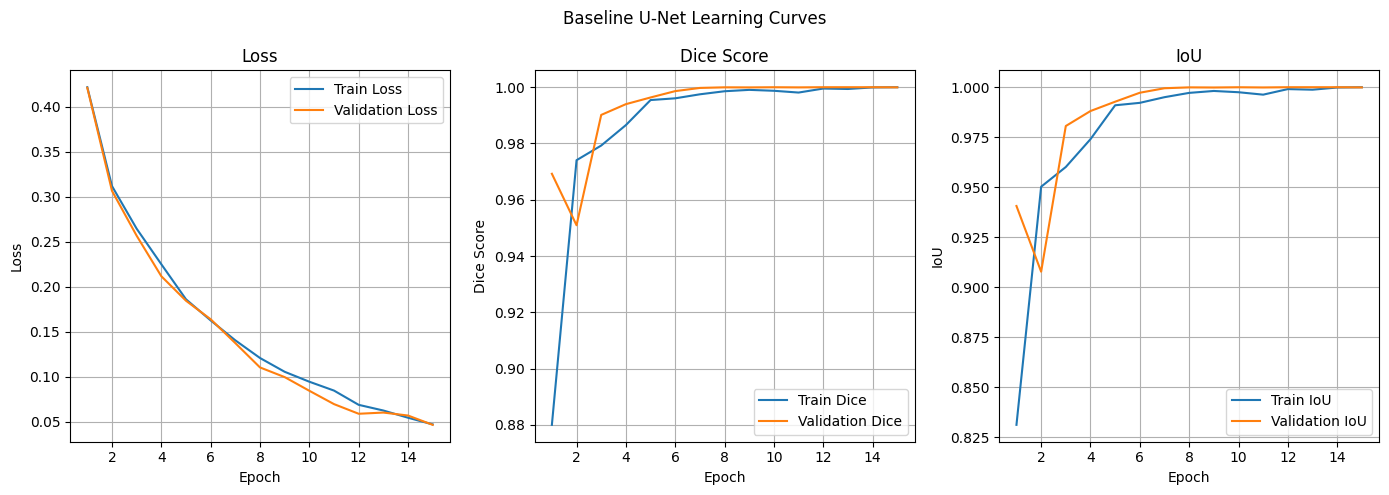

In [9]:
EPOCHS = 15

baseline_unet = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=32,
    dropout=0.0
).to(device)

baseline_history = train_unet_experiment(
    baseline_unet,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    learning_rate=0.001,
    experiment_name="Baseline U-Net"
)

plot_history(
    baseline_history,
    filename="images/tutorial_10_baseline_unet_learning_curves.png",
    title="Baseline U-Net Learning Curves"
)


## 9. Evaluate Baseline U-Net on Test Set

In [10]:
criterion = nn.BCEWithLogitsLoss()

baseline_test_loss, baseline_test_dice, baseline_test_iou = evaluate_model(
    baseline_unet,
    test_loader,
    criterion
)

print("Baseline U-Net Test Loss:", round(baseline_test_loss, 4))
print("Baseline U-Net Test Dice:", round(baseline_test_dice, 4))
print("Baseline U-Net Test IoU:", round(baseline_test_iou, 4))


Baseline U-Net Test Loss: 0.0464
Baseline U-Net Test Dice: 1.0
Baseline U-Net Test IoU: 1.0


## 10. Visualize Baseline U-Net Predictions

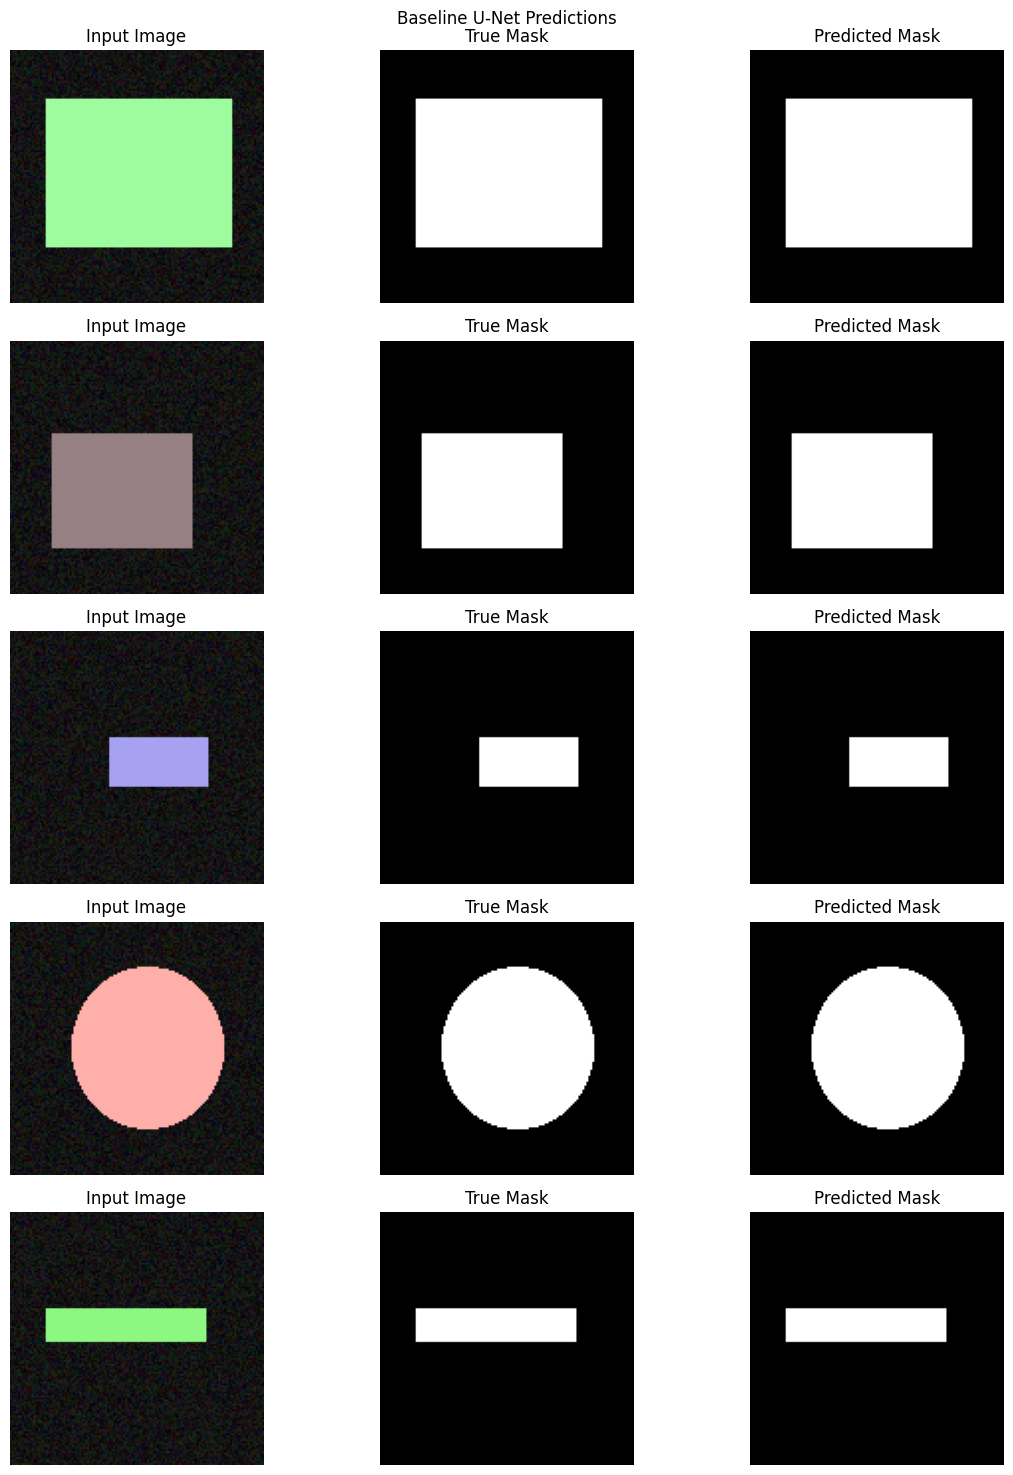

In [11]:
def visualize_predictions(model, loader, filename, title, n_samples=5):
    model.eval()

    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        logits = model(images)
        predictions = torch.sigmoid(logits)
        predictions = (predictions > 0.5).float()

    images = images.cpu()
    masks = masks.cpu()
    predictions = predictions.cpu()

    n_samples = min(n_samples, images.shape[0])

    plt.figure(figsize=(12, 3 * n_samples))

    for i in range(n_samples):
        image_np = images[i].permute(1, 2, 0).numpy()
        true_mask_np = masks[i, 0].numpy()
        pred_mask_np = predictions[i, 0].numpy()

        plt.subplot(n_samples, 3, i * 3 + 1)
        plt.imshow(image_np)
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(n_samples, 3, i * 3 + 2)
        plt.imshow(true_mask_np, cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(n_samples, 3, i * 3 + 3)
        plt.imshow(pred_mask_np, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


visualize_predictions(
    baseline_unet,
    test_loader,
    filename="images/tutorial_10_baseline_unet_predictions.png",
    title="Baseline U-Net Predictions",
    n_samples=5
)


# Part C — Change Layers

The task asks to change the model layers.

Here, a smaller U-Net is tested:

```text
base_channels = 16
```

This model has fewer channels and fewer parameters than the baseline model.


Baseline U-Net parameters: 1928417
Small U-Net parameters: 483441
Small U-Net | Epoch 1/15 | Train Loss: 0.5683 | Val Loss: 0.5908 | Train Dice: 0.7211 | Val Dice: 0.9521 | Train IoU: 0.6187 | Val IoU: 0.9093
Small U-Net | Epoch 2/15 | Train Loss: 0.4705 | Val Loss: 0.4775 | Train Dice: 0.9320 | Val Dice: 0.9405 | Train IoU: 0.8745 | Val IoU: 0.8897
Small U-Net | Epoch 3/15 | Train Loss: 0.4321 | Val Loss: 0.4273 | Train Dice: 0.9411 | Val Dice: 0.9302 | Train IoU: 0.8902 | Val IoU: 0.8719
Small U-Net | Epoch 4/15 | Train Loss: 0.3975 | Val Loss: 0.3929 | Train Dice: 0.9285 | Val Dice: 0.9222 | Train IoU: 0.8685 | Val IoU: 0.8586
Small U-Net | Epoch 5/15 | Train Loss: 0.3586 | Val Loss: 0.3654 | Train Dice: 0.9267 | Val Dice: 0.9668 | Train IoU: 0.8652 | Val IoU: 0.9365
Small U-Net | Epoch 6/15 | Train Loss: 0.3208 | Val Loss: 0.3222 | Train Dice: 0.9673 | Val Dice: 0.9729 | Train IoU: 0.9376 | Val IoU: 0.9477
Small U-Net | Epoch 7/15 | Train Loss: 0.2912 | Val Loss: 0.2801 | Train Dic

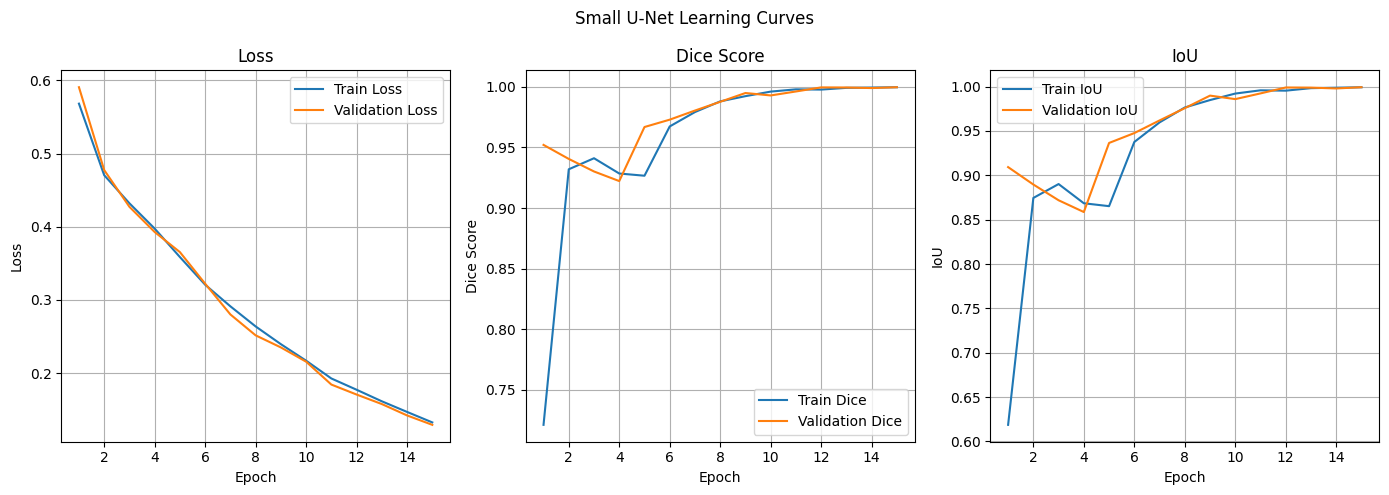

In [12]:
small_unet = UNet(
    in_channels=3,
    out_channels=1,
    base_channels=16,
    dropout=0.0
).to(device)

small_params = sum(p.numel() for p in small_unet.parameters())
baseline_params = sum(p.numel() for p in baseline_unet.parameters())

print("Baseline U-Net parameters:", baseline_params)
print("Small U-Net parameters:", small_params)

small_history = train_unet_experiment(
    small_unet,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    learning_rate=0.001,
    experiment_name="Small U-Net"
)

plot_history(
    small_history,
    filename="images/tutorial_10_small_unet_learning_curves.png",
    title="Small U-Net Learning Curves"
)


## 11. Evaluate Small U-Net

Small U-Net Test Loss: 0.1277
Small U-Net Test Dice: 0.9999
Small U-Net Test IoU: 0.9998


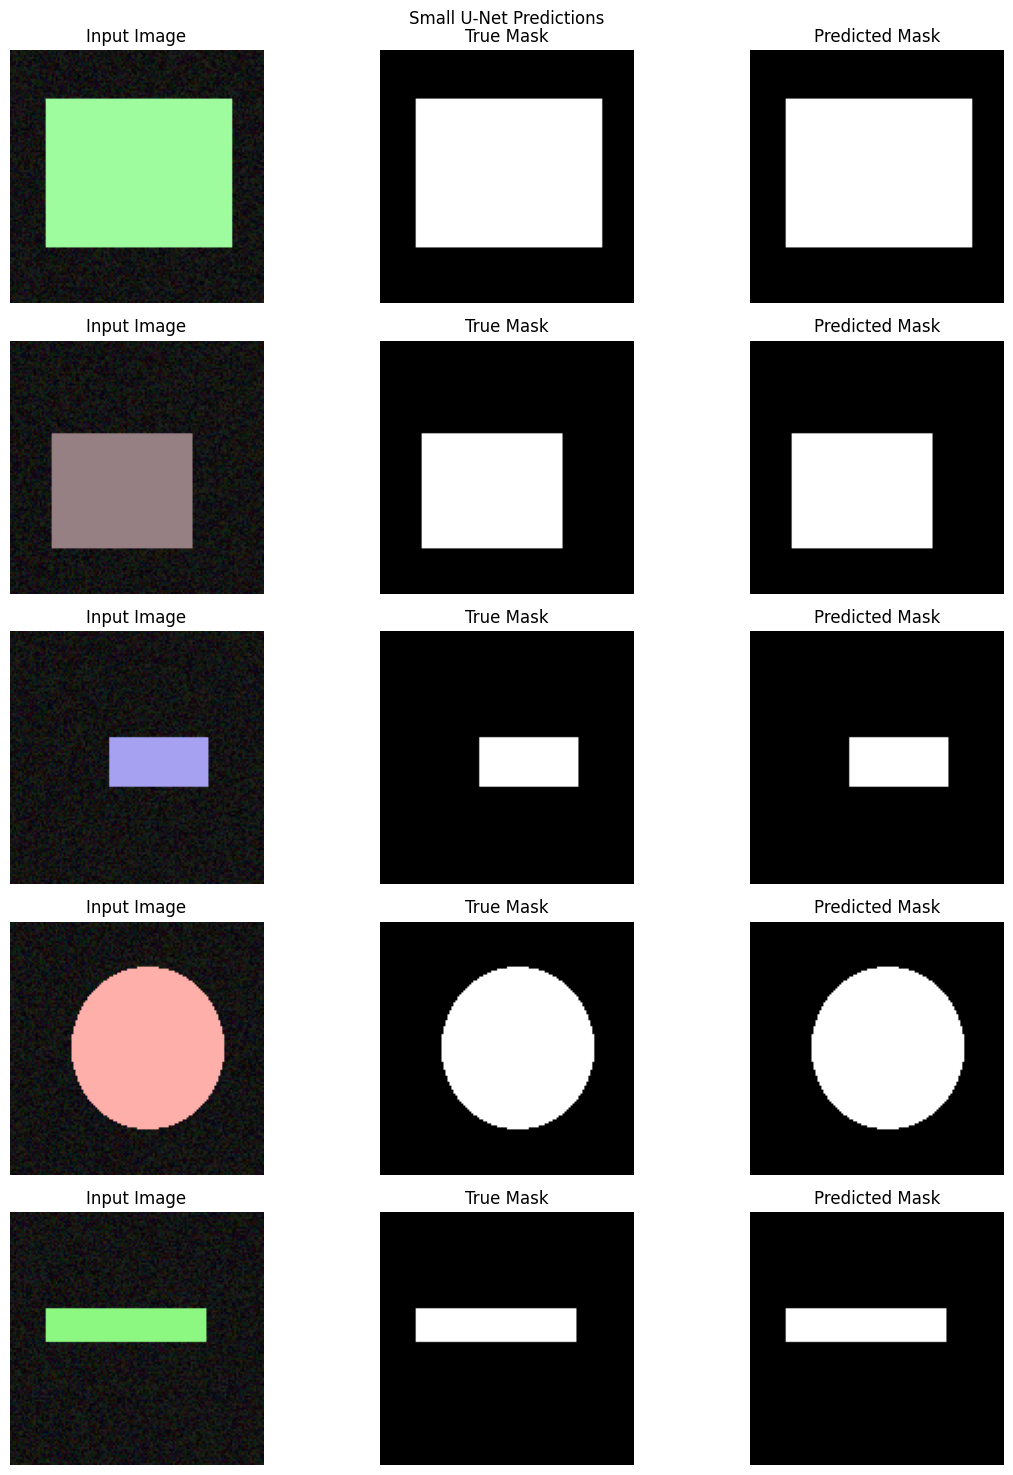

In [13]:
small_test_loss, small_test_dice, small_test_iou = evaluate_model(
    small_unet,
    test_loader,
    criterion
)

print("Small U-Net Test Loss:", round(small_test_loss, 4))
print("Small U-Net Test Dice:", round(small_test_dice, 4))
print("Small U-Net Test IoU:", round(small_test_iou, 4))

visualize_predictions(
    small_unet,
    test_loader,
    filename="images/tutorial_10_small_unet_predictions.png",
    title="Small U-Net Predictions",
    n_samples=5
)


# Part D — Different Learning Rates

The task also asks to use different learning rates and visualize results.

Here, the baseline U-Net architecture is trained with three learning rates:

```text
0.01
0.001
0.0001
```


In [14]:
learning_rates = [0.01, 0.001, 0.0001]
lr_results = []

for lr in learning_rates:
    print("\n" + "=" * 60)
    print("Training U-Net with learning rate:", lr)
    print("=" * 60)

    model_lr = UNet(
        in_channels=3,
        out_channels=1,
        base_channels=32,
        dropout=0.0
    ).to(device)

    history_lr = train_unet_experiment(
        model_lr,
        train_loader,
        val_loader,
        epochs=10,
        learning_rate=lr,
        experiment_name=f"U-Net LR={lr}"
    )

    test_loss, test_dice, test_iou = evaluate_model(
        model_lr,
        test_loader,
        criterion
    )

    lr_results.append({
        "Learning Rate": lr,
        "Final Train Loss": history_lr["train_loss"][-1],
        "Final Val Loss": history_lr["val_loss"][-1],
        "Test Loss": test_loss,
        "Test Dice": test_dice,
        "Test IoU": test_iou
    })

lr_results_df = pd.DataFrame(lr_results)
lr_results_df



Training U-Net with learning rate: 0.01
U-Net LR=0.01 | Epoch 1/10 | Train Loss: 0.2954 | Val Loss: 9.5900 | Train Dice: 0.8934 | Val Dice: 0.0000 | Train IoU: 0.8456 | Val IoU: 0.0000
U-Net LR=0.01 | Epoch 2/10 | Train Loss: 0.0553 | Val Loss: 5.2978 | Train Dice: 0.9886 | Val Dice: 0.0598 | Train IoU: 0.9777 | Val IoU: 0.0529
U-Net LR=0.01 | Epoch 3/10 | Train Loss: 0.0148 | Val Loss: 1.0001 | Train Dice: 0.9965 | Val Dice: 0.3168 | Train IoU: 0.9932 | Val IoU: 0.2533
U-Net LR=0.01 | Epoch 4/10 | Train Loss: 0.0089 | Val Loss: 0.0076 | Train Dice: 0.9920 | Val Dice: 0.9958 | Train IoU: 0.9855 | Val IoU: 0.9917
U-Net LR=0.01 | Epoch 5/10 | Train Loss: 0.0049 | Val Loss: 0.0094 | Train Dice: 0.9976 | Val Dice: 0.9972 | Train IoU: 0.9952 | Val IoU: 0.9944
U-Net LR=0.01 | Epoch 6/10 | Train Loss: 0.0035 | Val Loss: 0.0037 | Train Dice: 0.9985 | Val Dice: 0.9971 | Train IoU: 0.9970 | Val IoU: 0.9942
U-Net LR=0.01 | Epoch 7/10 | Train Loss: 0.0047 | Val Loss: 0.0031 | Train Dice: 0.9954 |

,Learning Rate,Final Train Loss,Final Val Loss,Test Loss,Test Dice,Test IoU
0,0.0100,0.001729,0.001367,0.001453,0.999694,0.999389
1,0.0010,0.058757,0.057459,0.057107,0.999992,0.999984
2,0.0001,0.284874,0.286683,0.283066,0.985521,0.971598


## 12. Visualize Learning Rate Comparison

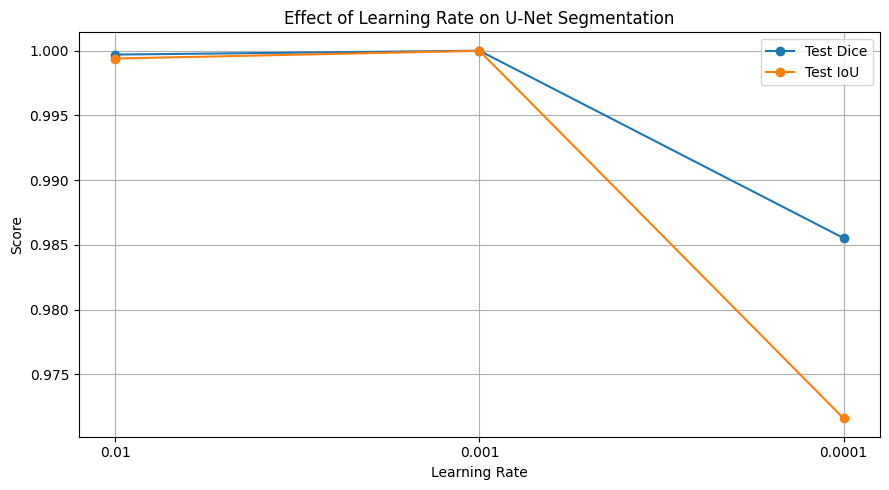

In [15]:
plt.figure(figsize=(9, 5))
plt.plot(lr_results_df["Learning Rate"].astype(str), lr_results_df["Test Dice"], marker="o", label="Test Dice")
plt.plot(lr_results_df["Learning Rate"].astype(str), lr_results_df["Test IoU"], marker="o", label="Test IoU")
plt.xlabel("Learning Rate")
plt.ylabel("Score")
plt.title("Effect of Learning Rate on U-Net Segmentation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/tutorial_10_learning_rate_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Save Final Results Table

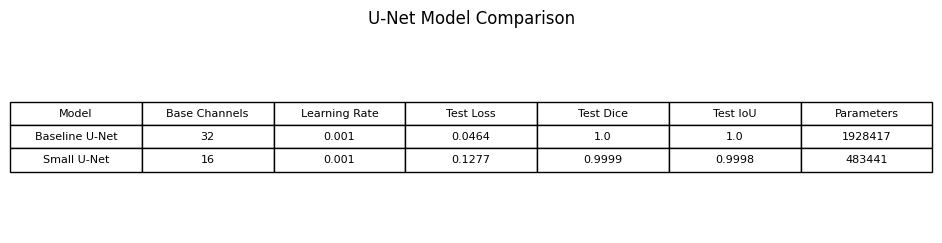

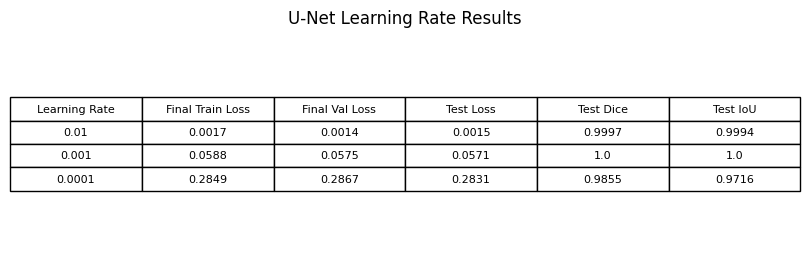

In [16]:
def save_dataframe_as_image(df, filename, title=None, fontsize=9):
    fig_width = max(8, len(df.columns) * 1.7)
    fig_height = max(2.5, len(df) * 0.5 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


summary_df = pd.DataFrame([
    {
        "Model": "Baseline U-Net",
        "Base Channels": 32,
        "Learning Rate": 0.001,
        "Test Loss": baseline_test_loss,
        "Test Dice": baseline_test_dice,
        "Test IoU": baseline_test_iou,
        "Parameters": baseline_params
    },
    {
        "Model": "Small U-Net",
        "Base Channels": 16,
        "Learning Rate": 0.001,
        "Test Loss": small_test_loss,
        "Test Dice": small_test_dice,
        "Test IoU": small_test_iou,
        "Parameters": small_params
    }
])

summary_display_df = summary_df.copy()

for column in ["Test Loss", "Test Dice", "Test IoU"]:
    summary_display_df[column] = summary_display_df[column].round(4)

save_dataframe_as_image(
    summary_display_df,
    "images/tutorial_10_model_comparison_table.png",
    title="U-Net Model Comparison",
    fontsize=8
)

lr_display_df = lr_results_df.copy()

for column in ["Final Train Loss", "Final Val Loss", "Test Loss", "Test Dice", "Test IoU"]:
    lr_display_df[column] = lr_display_df[column].round(4)

save_dataframe_as_image(
    lr_display_df,
    "images/tutorial_10_learning_rate_results_table.png",
    title="U-Net Learning Rate Results",
    fontsize=8
)


# Final Observations

## Dataset

A synthetic segmentation dataset was created using random shapes and binary masks.

## Baseline U-Net

The baseline U-Net was trained to predict binary masks from input images.

## Layer Change

A smaller U-Net was tested by reducing the number of base channels.

## Learning Rate Change

Different learning rates were tested to observe their effect on segmentation performance.

## Key Learning

Segmentation is different from classification and object detection.  
Instead of predicting only a class or a bounding box, the model predicts a label for every pixel.

U-Net is effective for segmentation because it combines encoder features with decoder upsampling using skip connections.
